# PROJECT: 45


## English ↔ Urdu Neural Machine Translation for Legal Documents

### First we  Import libraies

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from wordcloud import WordCloud

from collections import Counter

import re
import warnings
warnings.filterwarnings('ignore')
# Urdu font support
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Libraries loaded successfully!')



✅ Libraries loaded successfully!


In [19]:
# 1. Pehle pure Google Drive ko connect karein (is line ko bilkul aise hi likhna hai)
from google.colab import drive
drive.mount('/content/drive')

# 2. Drive connect hone ke baad, ab apna main path variable set karein
main_path = "/content/drive/MyDrive/project45_main/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###    PHASE : O1 DATASET LOAD:

In [21]:
df = pd.read_csv("/content/drive/MyDrive/project45_main/legal_dataset.csv")

df.head(3)


,english,urdu
0,IN THE SUPREME COURT OF PAKISTAN (Original Jur...,سپریم کورٹ آف پاکستان میں (اصل دائرہ اختیار) م...
1,"11 -15, 18 -22, 24, 31, 35, 36, 37 & 39-44/201...",11 -15، 18 -22، 24، 31، 35، 36، 37 اور 39-44/2...
2,"91/201 0, HRC Nos.20492 -P &22753 -K/10 and Ci...",91/201 0، HRC نمبر 20492 -P &22753 -K/10 اور س...


In [35]:
print(df.columns.tolist())
print(df.shape)
df.head()

['english', 'urdu']
(25002, 2)


,english,urdu
0,IN THE SUPREME COURT OF PAKISTAN (Original Jur...,سپریم کورٹ آف پاکستان میں (اصل دائرہ اختیار) م...
1,"11 -15, 18 -22, 24, 31, 35, 36, 37 & 39-44/201...",11 -15، 18 -22، 24، 31، 35، 36، 37 اور 39-44/2...
2,"91/201 0, HRC Nos.20492 -P &22753 -K/10 and Ci...",91/201 0، HRC نمبر 20492 -P &22753 -K/10 اور س...
3,"1901/2010 (On appeal from the order of PHC, Pe...",1901/2010 (پی ایچ سی، پشاور کے حکم سے اپیل پر ...
4,1581/10) Nadeem Ahmed Advocate ….,1581/10) ندیم احمد ایڈووکیٹ….


## PHASE : 02 PREPROCESSING

### GRAPHS BEFORE DATA CLEANING:

### 📈 Graph 1: Word Count Distribution (Bar Plot)

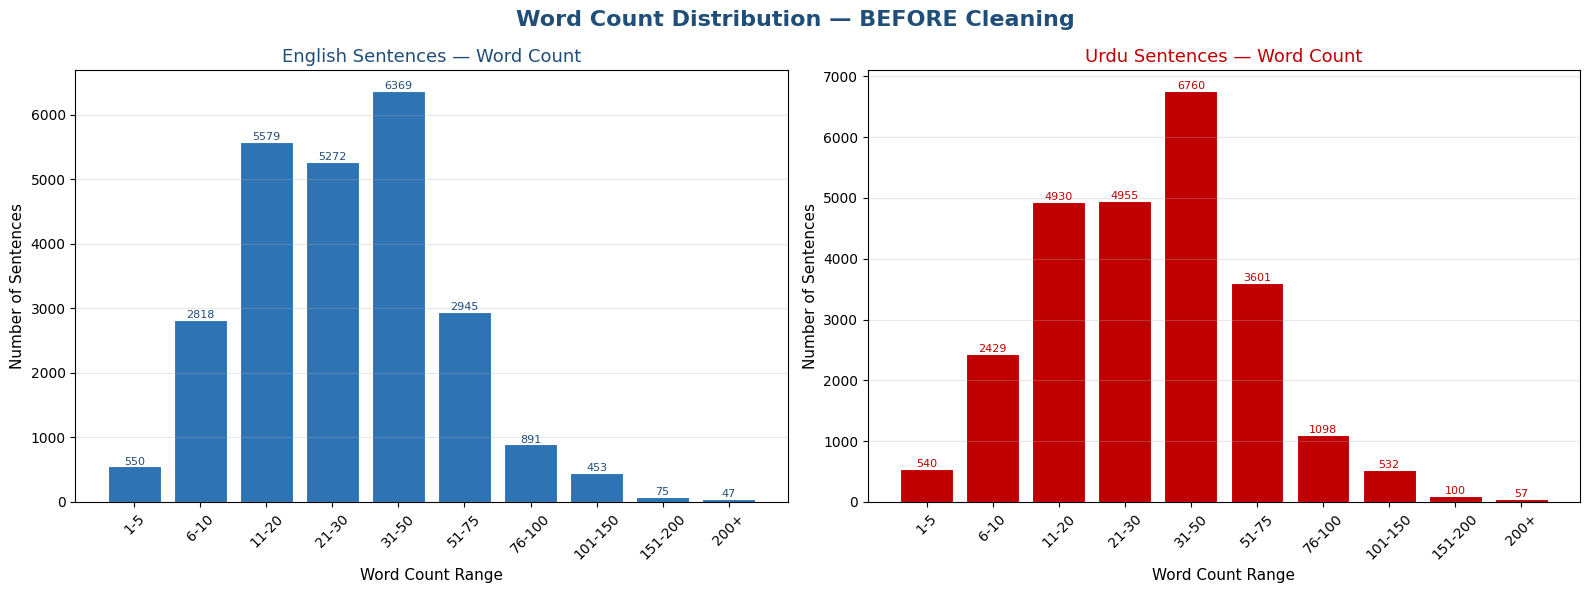

✅ Graph 1 saved!


In [36]:
# Word count per sentence
df['eng_word_count'] = df['english'].fillna('').apply(lambda x: len(str(x).split()))
df['urdu_word_count'] = df['urdu'].fillna('').apply(lambda x: len(str(x).split()))

# Bins for grouping
bins = [0, 5, 10, 20, 30, 50, 75, 100, 150, 200, 500]
labels = ['1-5','6-10','11-20','21-30','31-50','51-75','76-100','101-150','151-200','200+']

eng_dist = pd.cut(df['eng_word_count'], bins=bins, labels=labels).value_counts().sort_index()
urdu_dist = pd.cut(df['urdu_word_count'], bins=bins, labels=labels).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Count Distribution — BEFORE Cleaning', fontsize=16, fontweight='bold', color='#1F4E79')

axes[0].bar(eng_dist.index, eng_dist.values, color='#2E74B5', edgecolor='white', linewidth=0.8)
axes[0].set_title('English Sentences — Word Count', fontsize=13, color='#1F4E79')
axes[0].set_xlabel('Word Count Range', fontsize=11)
axes[0].set_ylabel('Number of Sentences', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(eng_dist.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=8, color='#1F4E79')

axes[1].bar(urdu_dist.index, urdu_dist.values, color='#C00000', edgecolor='white', linewidth=0.8)
axes[1].set_title('Urdu Sentences — Word Count', fontsize=13, color='#C00000')
axes[1].set_xlabel('Word Count Range', fontsize=11)
axes[1].set_ylabel('Number of Sentences', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(urdu_dist.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=8, color='#C00000')

plt.tight_layout()
plt.savefig('graph1_word_count_before_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 1 saved!')

## Graph 2: Scatter Plot

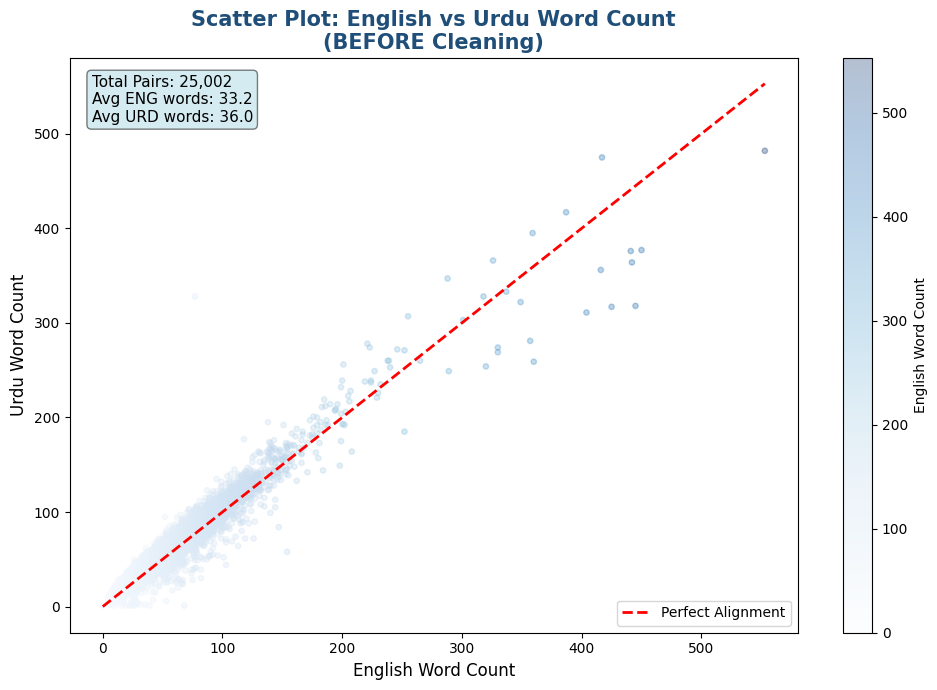

✅ Graph 2 saved!


In [37]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(df['eng_word_count'], df['urdu_word_count'],
                      c=df['eng_word_count'], cmap='Blues', alpha=0.3, s=15)

max_val = max(df['eng_word_count'].max(), df['urdu_word_count'].max())
ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Alignment')

ax.set_title('Scatter Plot: English vs Urdu Word Count\n(BEFORE Cleaning)', fontsize=15, fontweight='bold', color='#1F4E79')
ax.set_xlabel('English Word Count', fontsize=12)
ax.set_ylabel('Urdu Word Count', fontsize=12)
ax.legend(loc='lower right')

textstr = f"Total Pairs: {df.shape[0]:,}\nAvg ENG words: {df['eng_word_count'].mean():.1f}\nAvg URD words: {df['urdu_word_count'].mean():.1f}"
ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.colorbar(scatter, label='English Word Count')
plt.tight_layout()
plt.savefig('graph2_scatter_before_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 2 saved!')

### ☁️ Graph 3: Word Cloud — BEFORE Cleaning (English)

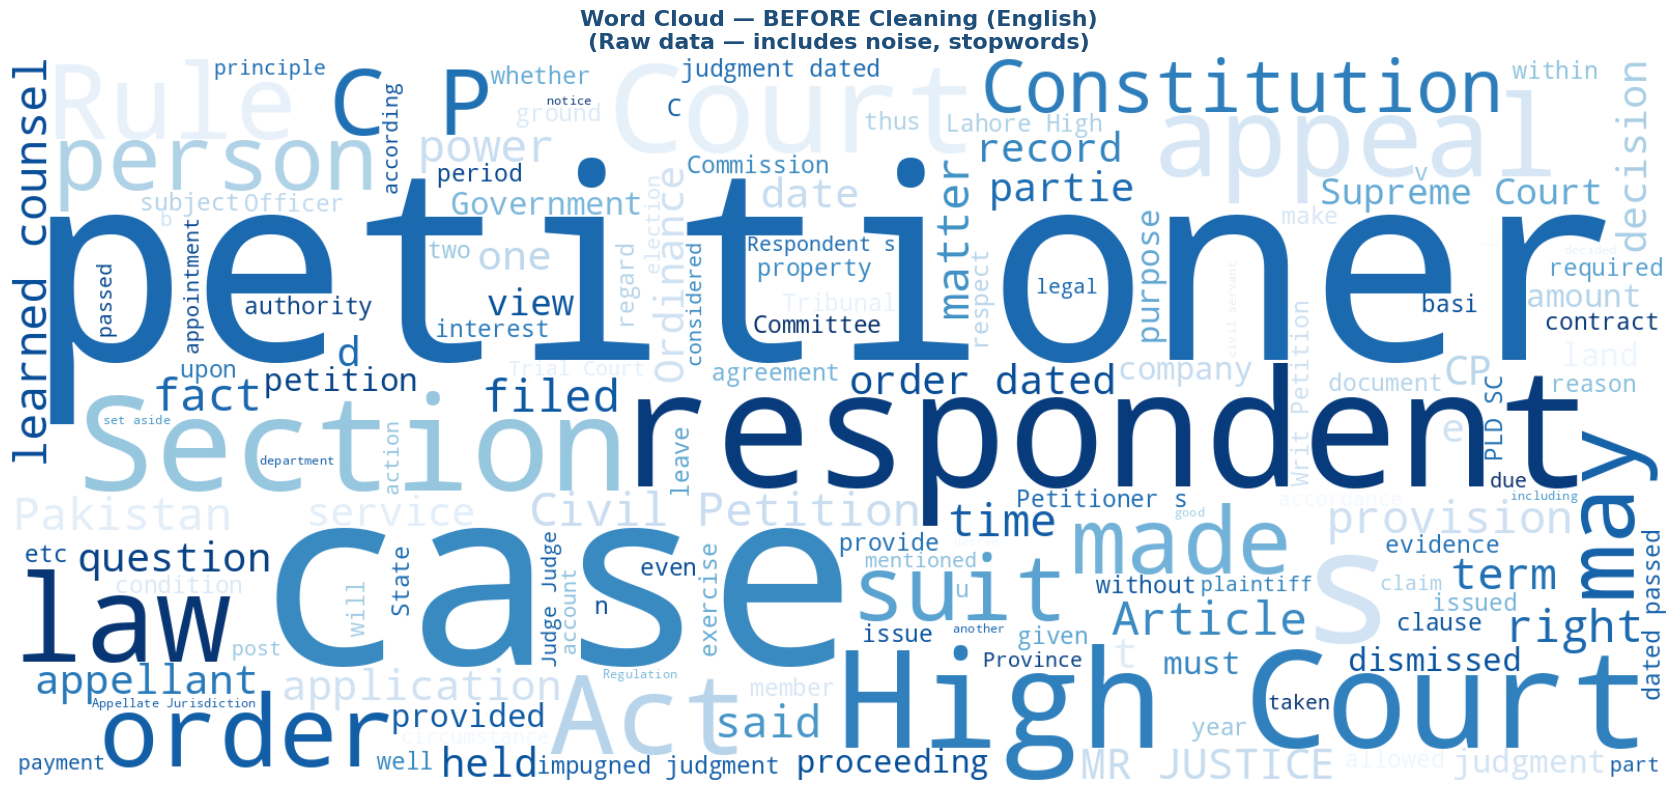

✅ Graph 3 saved!


In [38]:
# Combine all English text (raw, includes noise & stopwords)
all_text_before = " ".join(df['english'].fillna('').astype(str))

wordcloud_before = WordCloud(width=1600, height=700, background_color='white',
                               max_words=150, colormap='Blues').generate(all_text_before)

plt.figure(figsize=(18, 8))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.title('Word Cloud — BEFORE Cleaning (English)\n(Raw data — includes noise, stopwords)',
          fontsize=16, fontweight='bold', color='#1F4E79')
plt.axis('off')
plt.tight_layout()
plt.savefig('graph3_wordcloud_before_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 3 saved!')

### ☁️ Graph 3b: Word Cloud — BEFORE Cleaning (Urdu)

In [ ]:
# Combine all Urdu text (raw, includes noise & stopwords)
all_text_before_urdu = " ".join(df['urdu'].fillna('').astype(str))

wordcloud_before_urdu = WordCloud(width=1600, height=700, background_color='white',
                                    max_words=150, colormap='Reds',
                                    font_path='/usr/share/fonts/truetype/noto/NotoNastaliqUrdu-Regular.ttf'
                                    ).generate(all_text_before_urdu)

plt.figure(figsize=(18, 8))
plt.imshow(wordcloud_before_urdu, interpolation='bilinear')
plt.title('Word Cloud — BEFORE Cleaning (Urdu)\n(Raw data — includes noise, stopwords)',
          fontsize=16, fontweight='bold', color='#C00000')
plt.axis('off')
plt.tight_layout()
plt.savefig('graph3b_wordcloud_before_cleaning_urdu.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 3b (Urdu) saved!')


## PHASE: 03 DEEP DATA CLEANING


 #### Step 1: Missing values aur duplicates remove Code cell:

In [39]:
print(f"Before cleaning: {df.shape[0]} rows")

# Missing values (khali rows) remove karein
df.dropna(subset=['english', 'urdu'], inplace=True)

# Duplicate rows remove karein (english aur urdu dono check)
df.drop_duplicates(subset=['english'], inplace=True)
df.drop_duplicates(subset=['urdu'], inplace=True)

print(f"After removing Nulls & Duplicates: {df.shape[0]} rows")

Before cleaning: 25002 rows
After removing Nulls & Duplicates: 24955 rows


#### Step 2: Excel errors aur junk values remove

In [40]:
# Excel se aane wale error values (#VALUE!, #N/A, #REF! etc.) remove karein
junk_values = ['#VALUE!', '#N/A', '#REF!', '#DIV/0!', '#NULL!', '#NAME?', 'nan', 'NaN']
df = df[~df['english'].isin(junk_values)]
df = df[~df['urdu'].isin(junk_values)]

print(f"After removing junk/error values: {df.shape[0]} rows")

After removing junk/error values: 24954 rows


#### Step 3: Deep text cleaning function

In [41]:
def deep_clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. HTML tags remove karein
    text = re.sub(r'<[^>]+>', '', text)

    # 2. URLs remove karein
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. Control characters aur abnormal line breaks saaf karein
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

    # 4. Faltu white spaces ko ek single space mein badlein
    text = " ".join(text.split())

    return text.strip()

# Cleaning function apply karein
df['english'] = df['english'].apply(deep_clean_text)
df['urdu'] = df['urdu'].apply(deep_clean_text)

# Khali ho jaane wali rows ko dobara saaf karein
df = df[(df['english'] != "") & (df['urdu'] != "")]
print(f"After deep text cleaning: {df.shape[0]} rows")

After deep text cleaning: 24954 rows


#### Step 4: Length-based filtering (outliers remove)

In [42]:
# Word count calculate karein
df['eng_len'] = df['english'].apply(lambda x: len(x.split()))
df['urd_len'] = df['urdu'].apply(lambda x: len(x.split()))

# Sirf wo rows rakhein jahan words 3 se 100 ke darmiyan hon
# (Legal text thoda lamba hota hai isliye max limit 100 rakhi hai)
df_filtered = df[(df['eng_len'] >= 3) & (df['eng_len'] <= 100)]
df_filtered = df_filtered[(df_filtered['urd_len'] >= 3) & (df_filtered['urd_len'] <= 100)]

print(f"After Length Filtering: {df_filtered.shape[0]} rows")

After Length Filtering: 24201 rows


#### Step 5: Length ratio check (misaligned pairs hatana)

In [43]:
# English aur Urdu word count ka ratio nikalein
df_filtered['length_ratio'] = df_filtered['urd_len'] / df_filtered['eng_len']

# Extreme mismatch wale pairs hatayein (translation misalignment ka sign)
df_filtered = df_filtered[(df_filtered['length_ratio'] >= 0.3) & (df_filtered['length_ratio'] <= 3.0)]

print(f"After Length Ratio Filtering: {df_filtered.shape[0]} rows")

After Length Ratio Filtering: 24190 rows


In [44]:
# Quality score banane ke liye 2 factors use karenge:
# 1. Length Score: Medium-length sentences (15-60 words) ko zyada priority —
#    (na bohot chhotay jo context kam dete hain, na bohot lambay jo training slow karte hain)
# 2. Alignment Score: Jin pairs ka length_ratio 1.0 (perfect symmetry) ke jitna qareeb ho,
#    unko zyada priority (behtar translation alignment ka sign)

ideal_min, ideal_max = 15, 60

def length_score(word_count):
    if ideal_min <= word_count <= ideal_max:
        return 1.0  # Perfect range
    elif word_count < ideal_min:
        return word_count / ideal_min  # Chhotay sentences ko kam score
    else:
        return max(0, 1 - (word_count - ideal_max) / 100)  # Lambay sentences ko kam score

# English aur Urdu dono ke length scores nikalein
df_filtered['eng_length_score'] = df_filtered['eng_len'].apply(length_score)
df_filtered['urd_length_score'] = df_filtered['urd_len'].apply(length_score)

# Alignment score: ratio jitna 1.0 ke qareeb, utna behtar
df_filtered['alignment_score'] = 1 - abs(df_filtered['length_ratio'] - 1.0).clip(0, 1)

# Final combined quality score (teeno ka average)
df_filtered['quality_score'] = (
    df_filtered['eng_length_score'] +
    df_filtered['urd_length_score'] +
    df_filtered['alignment_score']
) / 3

# Quality score ke hisaab se sort karein (best pehle)
df_sorted = df_filtered.sort_values(by='quality_score', ascending=False)

# Top 20,000 best quality rows select karein
if df_sorted.shape[0] >= 20000:
    df_final = df_sorted.head(20000).reset_index(drop=True)
else:
    df_final = df_sorted.reset_index(drop=True)

# Shuffle karein taake training ke waqt order-bias na ho (lekin yeh sirf row order hai, content same rahega)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Sirf main translation columns rakhein (helper columns drop)
df_final = df_final[['english', 'urdu']]

print(f"✅ Final Best-Quality Data Size: {df_final.shape[0]} rows")
print(f"\nAverage quality score of selected rows: {df_sorted.head(20000)['quality_score'].mean():.3f}")
df_final.head(10)

✅ Final Best-Quality Data Size: 20000 rows

Average quality score of selected rows: 0.938


,english,urdu
0,"36 Farhana Sultana, ‘ Water justice: why it ma...",36 فرحانہ سلطانہ، 'پانی کا انصاف: یہ کیوں اہمی...
1,This order is being passed in line with the or...,یہ حکم اس عدالت کی جانب سے بل بورڈز/ہورڈنگز کے...
2,The fact remains that the petitioner had alleg...,حقیقت یہ ہے کہ درخواست گزار نے الزام لگایا تھا...
3,The learned Trial Court v ide judgment and dec...,24.02.2016 کو دیے گئے فیصلہ اور حکم نامے نے مق...
4,The Tribunal vide its decision held that appel...,ٹربیونل نے اپنے فیصلے کے ذریعے کہا کہ اپیل کنن...
5,"Finally, the said writ petitions were dismisse...",آخر کار، علاقائی دائرہ اختیار نہ ہونے کی وجہ س...
6,"Each employee, however, had the option to rema...",تاہم، ہر ملازم کے پاس پرانی پنشن اسکیم پر رہنے...
7,Pursuant to a detailed Order dated 05.10.2015 ...,اس عدالت کے 05.10.2015 کے تفصیلی حکم کے مطابق،...
8,"Briefly, the facts of the case are that the Pl...",مختصراً، کیس کے حقائق یہ ہیں کہ مدعی/جواب دینے...
9,"In light of what has been discussed above, as ...",اوپر جو بات کی گئی ہے اس کی روشنی میں، عام اصو...


## PHASE: 04 STOPWORDS REMOVAL (for Analysis & Classical ML features)

In [45]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# English stopwords (comprehensive NLTK list)
eng_stopwords = set(stopwords.words('english'))

# Urdu stopwords (comprehensive curated list)
urdu_stopwords = set([
    "کے", "کی", "کا", "کو", "ہے", "ہیں", "اور", "سے", "میں", "پر", "کر", "نہیں", "تو",
    "ہو", "گا", "گی", "گے", "تھا", "تھی", "تھے", "نے", "کہ", "یہ", "وہ", "ان", "اس", "جو",
    "اپنے", "اپنی", "اپنا", "ہی", "بھی", "اگر", "لیکن", "یا", "جس", "جن", "ہر", "ہم",
    "آپ", "تم", "ایک", "دو", "سب", "کچھ", "کوئی", "تک", "بعد", "پہلے", "لیے", "بغیر",
    "اندر", "باہر", "اوپر", "نیچے", "درمیان", "ساتھ", "خلاف", "مطابق", "ذریعے"
])

print(f"English stopwords count: {len(eng_stopwords)}")
print(f"Urdu stopwords count: {len(urdu_stopwords)}")
print("✅ Stopwords lists created!")

English stopwords count: 198
Urdu stopwords count: 60
✅ Stopwords lists created!


In [46]:
def remove_stopwords(text, stopwords_set):
    words = text.split()
    filtered = [w for w in words if w.lower() not in stopwords_set and len(w) > 1]
    return " ".join(filtered)

# Naye columns banayein — analysis/classical ML ke liye (transformer training ke liye df_final asli rakhein)
df_final['english_no_stopwords'] = df_final['english'].apply(lambda x: remove_stopwords(x, eng_stopwords))
df_final['urdu_no_stopwords'] = df_final['urdu'].apply(lambda x: remove_stopwords(x, urdu_stopwords))

print("✅ Stopwords removed — saved in separate columns")
df_final[['english', 'english_no_stopwords']].head(5)

✅ Stopwords removed — saved in separate columns


,english,english_no_stopwords
0,"36 Farhana Sultana, ‘ Water justice: why it ma...","36 Farhana Sultana, Water justice: matters ach..."
1,This order is being passed in line with the or...,order passed line order passed Court suo motu ...
2,The fact remains that the petitioner had alleg...,fact remains petitioner alleged oral agreement...
3,The learned Trial Court v ide judgment and dec...,learned Trial Court ide judgment decree dated ...
4,The Tribunal vide its decision held that appel...,Tribunal vide decision held appellant acquitte...


### ☁️ Graph 4: Word Cloud — AFTER Cleaning + Stopwords Removed (English)

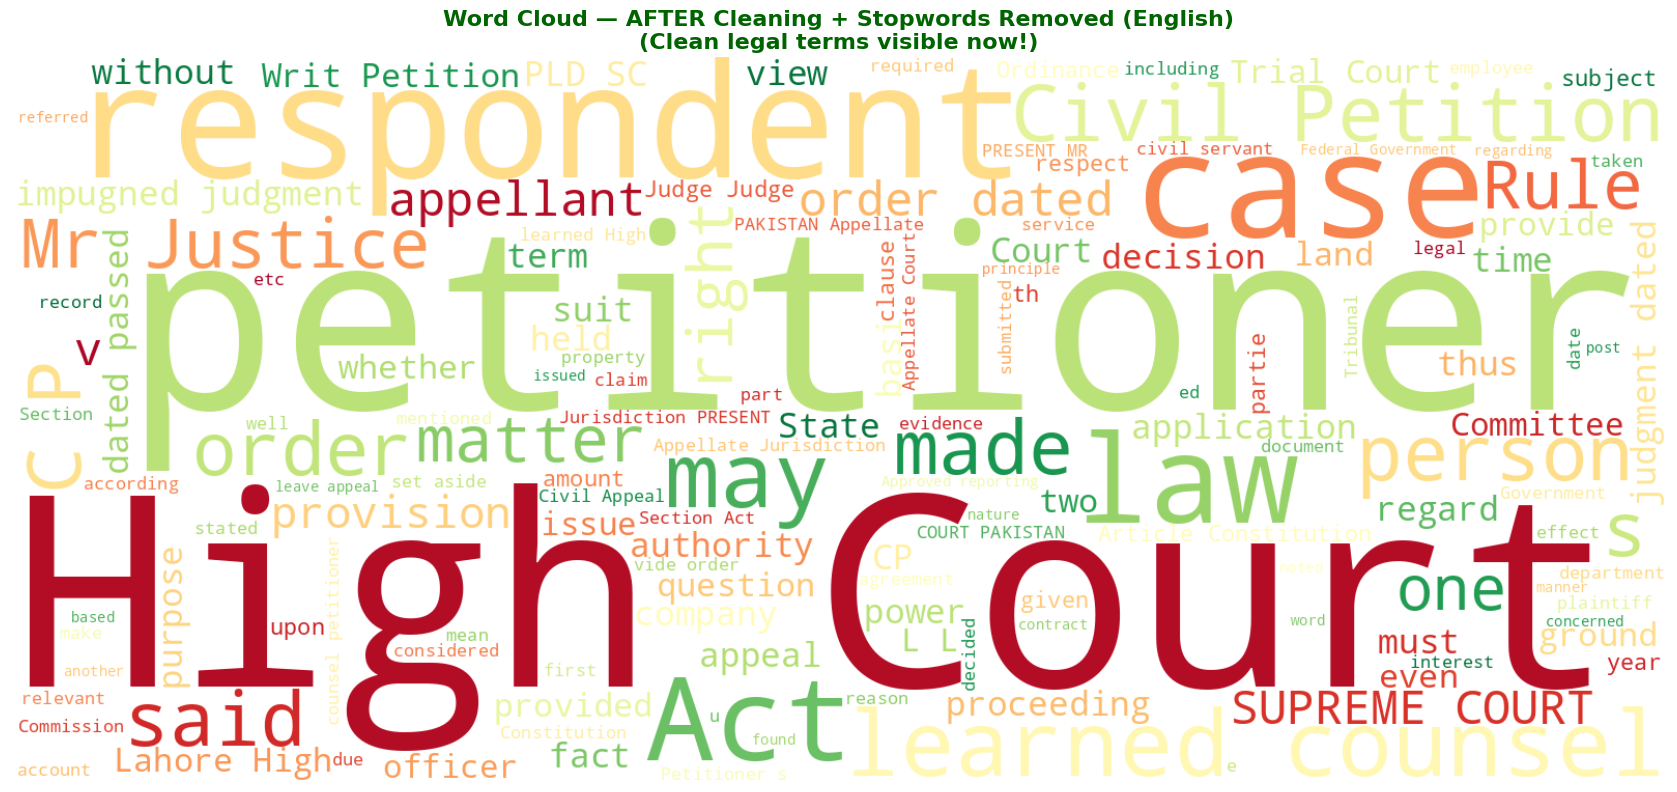

✅ Graph 4 saved!


In [47]:
clean_text_after = " ".join(df_final['english_no_stopwords'])

wordcloud_after = WordCloud(width=1600, height=700, background_color='white',
                              max_words=150, colormap='RdYlGn').generate(clean_text_after)

plt.figure(figsize=(18, 8))
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.title('Word Cloud — AFTER Cleaning + Stopwords Removed (English)\n(Clean legal terms visible now!)',
          fontsize=16, fontweight='bold', color='darkgreen')
plt.axis('off')
plt.tight_layout()
plt.savefig('graph4_wordcloud_after_stopwords.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 4 saved!')

### ☁️ Graph 4b: Word Cloud — AFTER Cleaning + Stopwords Removed (Urdu)

In [ ]:
clean_text_after_urdu = " ".join(df_final['urdu_no_stopwords'])

wordcloud_after_urdu = WordCloud(width=1600, height=700, background_color='white',
                                   max_words=150, colormap='RdYlGn',
                                   font_path='/usr/share/fonts/truetype/noto/NotoNastaliqUrdu-Regular.ttf'
                                   ).generate(clean_text_after_urdu)

plt.figure(figsize=(18, 8))
plt.imshow(wordcloud_after_urdu, interpolation='bilinear')
plt.title('Word Cloud — AFTER Cleaning + Stopwords Removed (Urdu)\n(Clean legal terms visible now!)',
          fontsize=16, fontweight='bold', color='darkgreen')
plt.axis('off')
plt.tight_layout()
plt.savefig('graph4b_wordcloud_after_stopwords_urdu.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 4b (Urdu) saved!')


### 📈 Graph 5: Word Count Distribution — AFTER Cleaning (Comparison)

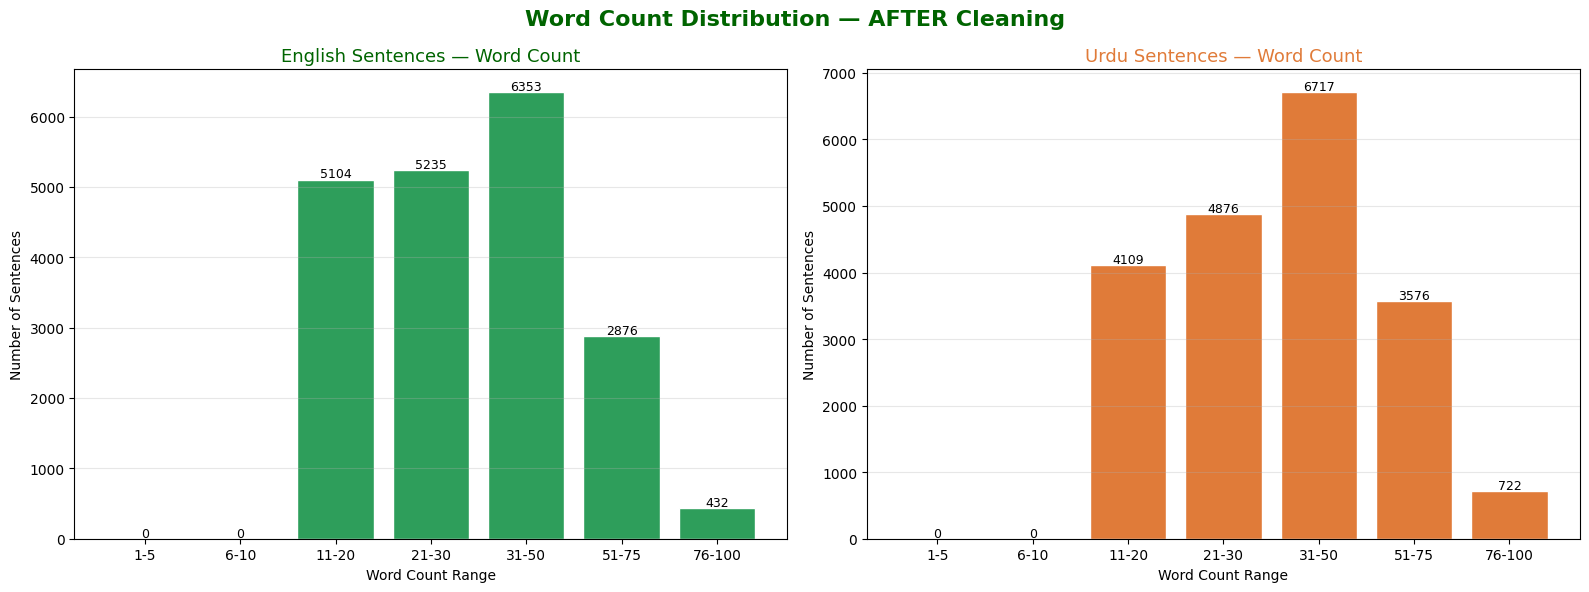

✅ Graph 5 saved!


In [48]:
df_final['eng_word_count'] = df_final['english'].apply(lambda x: len(x.split()))
df_final['urd_word_count'] = df_final['urdu'].apply(lambda x: len(x.split()))

bins2 = [0, 5, 10, 20, 30, 50, 75, 100]
labels2 = ['1-5','6-10','11-20','21-30','31-50','51-75','76-100']

eng_dist_after = pd.cut(df_final['eng_word_count'], bins=bins2, labels=labels2).value_counts().sort_index()
urdu_dist_after = pd.cut(df_final['urd_word_count'], bins=bins2, labels=labels2).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Count Distribution — AFTER Cleaning', fontsize=16, fontweight='bold', color='darkgreen')

axes[0].bar(eng_dist_after.index, eng_dist_after.values, color='#2E9E5B', edgecolor='white')
axes[0].set_title('English Sentences — Word Count', fontsize=13, color='darkgreen')
axes[0].set_xlabel('Word Count Range')
axes[0].set_ylabel('Number of Sentences')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(eng_dist_after.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

axes[1].bar(urdu_dist_after.index, urdu_dist_after.values, color='#E07B39', edgecolor='white')
axes[1].set_title('Urdu Sentences — Word Count', fontsize=13, color='#E07B39')
axes[1].set_xlabel('Word Count Range')
axes[1].set_ylabel('Number of Sentences')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(urdu_dist_after.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('graph5_word_count_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 5 saved!')

### 📈 Graph 6: Scatter Plot — English vs Urdu Word Count (AFTER Cleaning)

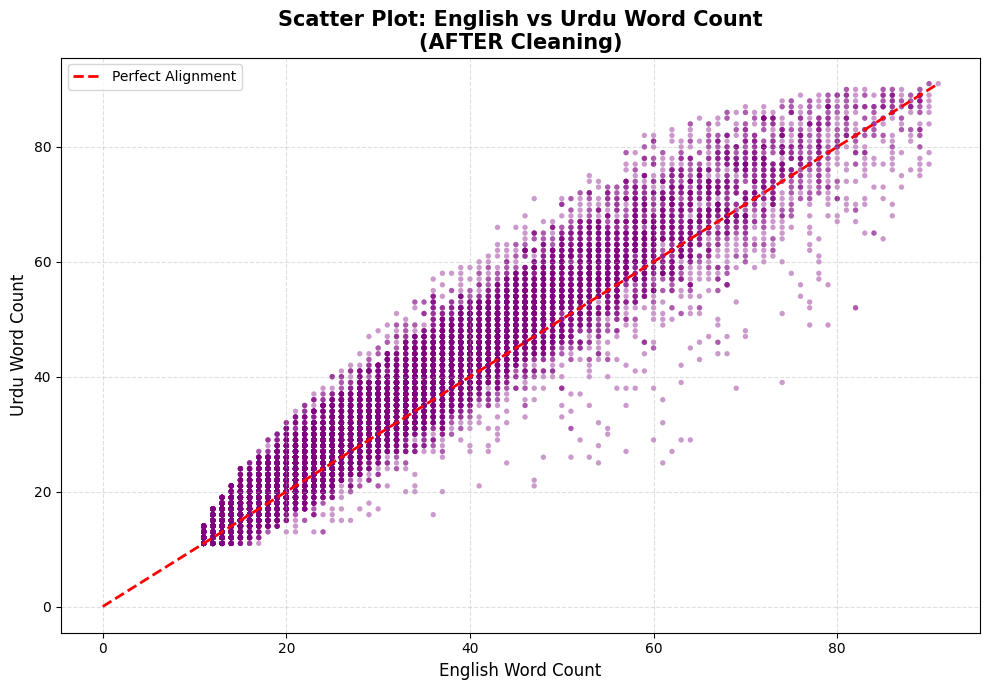

✅ Graph 6 saved!


In [49]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_final['eng_word_count'], df_final['urd_word_count'],
           alpha=0.4, color='purple', edgecolor='none', s=15)

max_len = max(df_final['eng_word_count'].max(), df_final['urd_word_count'].max())
ax.plot([0, max_len], [0, max_len], color='red', linestyle='--', linewidth=2, label='Perfect Alignment')

ax.set_title('Scatter Plot: English vs Urdu Word Count\n(AFTER Cleaning)', fontsize=15, fontweight='bold')
ax.set_xlabel('English Word Count', fontsize=12)
ax.set_ylabel('Urdu Word Count', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('graph6_scatter_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graph 6 saved!')

In [50]:
# Final cleaned dataset save karein (transformer training ke liye)
df_final[['english', 'urdu']].to_csv('cleaned_dataset.csv', index=False, encoding='utf-8-sig')
print("✅ cleaned_dataset.csv saved successfully!")
print(f"Final shape: {df_final.shape[0]} rows")

✅ cleaned_dataset.csv saved successfully!
Final shape: 20000 rows


## PHASE: 05 NER MASKING
Case numbers, dates, aur judge/person names ko special tags se mask kar rahe hain — taake model sirf legal sentence structure seekhe, specific names/numbers ko "memorize" na kare.

In [51]:
!pip install spacy --quiet
!python -m spacy download en_core_web_sm --quiet
print("✅ spaCy installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ spaCy installed!


#### Step 2: NER model load karna

In [52]:
import spacy
nlp = spacy.load("en_core_web_sm")

print("✅ NER model loaded!")

✅ NER model loaded!


#### Step 3: Masking function banana (regex + NER dono combine)

In [53]:
# Generic legal terms jo mask NAHI hone chahiye
legal_terms_exclude = {
    "court", "trial court", "high court", "supreme court", "tribunal",
    "bench", "session court", "civil court", "appellate court",
    "constitution", "ordinance", "act", "section", "article"
}

def mask_entities(text):
    if not isinstance(text, str) or text.strip() == "":
        return text

    # 1. Case numbers mask karein
    text = re.sub(r'\b[A-Z]{0,5}\s?\d{1,5}[-/]\d{2,4}\b', '<CASENUM>', text)

    # 2. Dates mask karein
    text = re.sub(r'\b\d{1,2}[./-]\d{1,2}[./-]\d{2,4}\b', '<DATE>', text)

    # 3. spaCy NER se Person aur Organization names mask karein (generic terms chhod kar)
    doc = nlp(text)
    masked_text = text
    for ent in reversed(doc.ents):
        entity_text_lower = ent.text.lower().strip()

        # Agar yeh generic legal term hai, to skip kar dein (mask na karein)
        if entity_text_lower in legal_terms_exclude:
            continue

        if ent.label_ == "PERSON":
            masked_text = masked_text[:ent.start_char] + "<PERSON>" + masked_text[ent.end_char:]
        elif ent.label_ in ["ORG", "GPE"]:
            masked_text = masked_text[:ent.start_char] + "<ORG>" + masked_text[ent.end_char:]

    return masked_text

print("✅ Updated masking function ready!")

✅ Updated masking function ready!


### Step 4: Test karna ek sample par

In [54]:
sample_text = df_final['english'].iloc[0]
masked_sample = mask_entities(sample_text)

print("Original:", sample_text)
print("\nMasked:", masked_sample)

Original: 36 Farhana Sultana, ‘ Water justice: why it matters and how to achieve it’ (2018) 43 Water International 483.

Masked: 36 <PERSON>, ‘ Water justice: why it matters and how to achieve it’ (2018) 43 Water International 483.


#### Step 5: Poore dataset par apply karna

In [55]:
# Sirf English par NER masking apply karenge (legal entities English mein zyada structured hoti hain)
df_final['english_masked'] = df_final['english'].apply(mask_entities)

print("✅ NER Masking complete!")
df_final[['english', 'english_masked']].head(5)

✅ NER Masking complete!


,english,english_masked
0,"36 Farhana Sultana, ‘ Water justice: why it ma...","36 <PERSON>, ‘ Water justice: why it matters a..."
1,This order is being passed in line with the or...,This order is being passed in line with the or...
2,The fact remains that the petitioner had alleg...,The fact remains that the petitioner had alleg...
3,The learned Trial Court v ide judgment and dec...,The learned Trial Court v ide judgment and dec...
4,The Tribunal vide its decision held that appel...,The Tribunal vide its decision held that appel...


## PHASE: 05.5 LEGAL TERM GLOSSARY
Dataset mein common legal terms ki ek English-Urdu glossary bana rahe hain — taake translation consistency check ki ja sake.

In [56]:
# Pakistani legal documents mein commonly aane wale terms
legal_glossary = {
    "petitioner": "درخواست گزار",
    "respondent": "مدعا علیہ",
    "court": "عدالت",
    "judgment": "فیصلہ",
    "appeal": "اپیل",
    "petition": "درخواست",
    "order": "حکم",
    "act": "ایکٹ",
    "section": "دفعہ",
    "article": "آرٹیکل",
    "constitution": "آئین",
    "jurisdiction": "دائرہ اختیار",
    "plaintiff": "مدعی",
    "defendant": "مدعا علیہ",
    "evidence": "ثبوت",
    "counsel": "وکیل",
    "high court": "ہائی کورٹ",
    "supreme court": "سپریم کورٹ",
    "civil": "دیوانی",
    "criminal": "فوجداری",
    "appellant": "اپیل کنندہ",
    "writ": "رٹ",
    "decree": "ڈگری",
    "tribunal": "ٹربیونل",
    "ordinance": "آرڈیننس",
}

print(f"✅ Legal Glossary created with {len(legal_glossary)} terms!")
for eng, urd in list(legal_glossary.items())[:5]:
    print(f"{eng} → {urd}")

✅ Legal Glossary created with 25 terms!
petitioner → درخواست گزار
respondent → مدعا علیہ
court → عدالت
judgment → فیصلہ
appeal → اپیل


In [57]:
# Glossary ko CSV mein save karein (documentation/reference ke liye)
import pandas as pd

glossary_df = pd.DataFrame(list(legal_glossary.items()), columns=['english_term', 'urdu_term'])
glossary_df.to_csv('legal_term_glossary.csv', index=False, encoding='utf-8-sig')

print("✅ legal_term_glossary.csv saved!")
glossary_df

✅ legal_term_glossary.csv saved!


,english_term,urdu_term
0,petitioner,درخواست گزار
1,respondent,مدعا علیہ
2,court,عدالت
3,judgment,فیصلہ
4,appeal,اپیل
5,petition,درخواست
6,order,حکم
7,act,ایکٹ
8,section,دفعہ
9,article,آرٹیکل


## PHASE: 06 TOKENIZATION (Transformer-based: mBART-50 / NLLB-200)
Transformer models apna pre-trained SentencePiece tokenizer use karte hain. Hum khud se vocabulary build nahi karte — balke pre-trained tokenizer load kar ke apna cleaned data usse encode karte hain.

In [58]:
!pip install transformers sentencepiece datasets --quiet
print("✅ Libraries installed!")

✅ Libraries installed!


In [59]:
from transformers import MBart50TokenizerFast

# mBART-50 ka multilingual tokenizer load karein
model_checkpoint = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = MBart50TokenizerFast.from_pretrained(model_checkpoint)

print("✅ mBART-50 Tokenizer loaded successfully!")
print(f"Vocabulary size: {tokenizer.vocab_size}")

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

✅ mBART-50 Tokenizer loaded successfully!
Vocabulary size: 250054


#### Step 3: Language codes set karna

In [60]:
# English = source language, Urdu = target language
tokenizer.src_lang = "en_XX"
tgt_lang_code = "ur_PK"

print("Source language (English):", tokenizer.src_lang)
print("Target language (Urdu):", tgt_lang_code)

Source language (English): en_XX
Target language (Urdu): ur_PK


#### Step 4: Ek sample sentence par test karna

In [61]:
sample_eng = df_final['english_masked'].iloc[0]
sample_urd = df_final['urdu'].iloc[0]

print("Original English:", sample_eng)
print("Original Urdu:", sample_urd)

# English tokenize (source)
encoded_eng = tokenizer(sample_eng, return_tensors="pt")
print("\nEnglish Token IDs (first 20):", encoded_eng['input_ids'][0][:20].tolist())

# Urdu tokenize (target) — naya tareeqa: text_target parameter
encoded_urd = tokenizer(text_target=sample_urd, return_tensors="pt")
print("Urdu Token IDs (first 20):", encoded_urd['input_ids'][0][:20].tolist())

Original English: 36 <PERSON>, ‘ Water justice: why it matters and how to achieve it’ (2018) 43 Water International 483.
Original Urdu: 36 فرحانہ سلطانہ، 'پانی کا انصاف: یہ کیوں اہمیت رکھتا ہے اور اسے کیسے حاصل کیا جائے' (2018) 43 واٹر انٹرنیشنل 483۔

English Token IDs (first 20): [250004, 4039, 4426, 30425, 58627, 2740, 4, 204, 27646, 87338, 12, 15400, 442, 26866, 7, 136, 3642, 47, 69307, 442]
Urdu Token IDs (first 20): [250004, 4039, 6, 127840, 26048, 80797, 907, 50, 242, 109264, 140, 499, 26160, 12, 1938, 34117, 142085, 141768, 639, 490]


#### Step 5: Train-Validation split karna

In [62]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_final, test_size=0.1, random_state=42)

print(f"Training rows: {train_df.shape[0]}")
print(f"Validation rows: {val_df.shape[0]}")

Training rows: 18000
Validation rows: 2000


#### Step 6: HuggingFace Dataset format mein convert karna

In [63]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

print("✅ Converted to HuggingFace Dataset format!")
print(train_dataset)

✅ Converted to HuggingFace Dataset format!
Dataset({
    features: ['english', 'urdu', 'english_no_stopwords', 'urdu_no_stopwords', 'eng_word_count', 'urd_word_count', 'english_masked'],
    num_rows: 18000
})


#### Step 7: Poora dataset tokenize karna (function banana)

In [64]:
MAX_LENGTH = 100

def tokenize_function(examples):
    model_inputs = tokenizer(
        examples['english_masked'],
        text_target=examples['urdu'],   # naya tareeqa — ek hi call mein source + target
        max_length=MAX_LENGTH,
        truncation=True,
        padding='max_length'
    )
    return model_inputs

print("✅ Tokenization function ready!")

✅ Tokenization function ready!


 #### Step 8: Function ko poore dataset par apply karna

In [65]:
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=['english', 'urdu'])
tokenized_val = val_dataset.map(tokenize_function, batched=True, remove_columns=['english', 'urdu'])

print("✅ Tokenization complete!")
print(f"Tokenized training samples: {len(tokenized_train)}")
print(f"Tokenized validation samples: {len(tokenized_val)}")

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Tokenization complete!
Tokenized training samples: 18000
Tokenized validation samples: 2000


#### Step 9: Verify karna (sanity check — decode kar ke wapas check karna)

In [66]:
sample_idx = 0
input_ids = tokenized_train[sample_idx]['input_ids']
label_ids = tokenized_train[sample_idx]['labels']

decoded_input = tokenizer.decode(input_ids, skip_special_tokens=True)
decoded_label = tokenizer.decode(label_ids, skip_special_tokens=True)

print("Decoded English (from tokens):", decoded_input)
print("\nDecoded Urdu (from tokens):", decoded_label)
print("\n✅ Agar yeh original sentences se match karein, tokenization sahi hui!")

Decoded English (from tokens): When a part of the consolidated judgment is not challenged and remains intact <ORG>

Decoded Urdu (from tokens): جب متفقہ فیصلے کے کسی حصے کو چیلنج نہیں کیا جاتا اور C.P.L.A برقرار رہتا ہے۔

✅ Agar yeh original sentences se match karein, tokenization sahi hui!


In [67]:
print("Original (unmasked):", df_final['english'].iloc[0])
print("\nMasked version:", df_final['english_masked'].iloc[0])

Original (unmasked): 36 Farhana Sultana, ‘ Water justice: why it matters and how to achieve it’ (2018) 43 Water International 483.

Masked version: 36 <PERSON>, ‘ Water justice: why it matters and how to achieve it’ (2018) 43 Water International 483.


In [68]:
print("Train dataset row 0 - english_masked:", train_dataset[0]['english_masked'])
print("\nTokenized + decoded (Step 9 wala):", decoded_input)

Train dataset row 0 - english_masked: When a part of the consolidated judgment is not challenged and remains intact <ORG>

Tokenized + decoded (Step 9 wala): When a part of the consolidated judgment is not challenged and remains intact <ORG>


In [69]:
import torch

print("CUDA (GPU) available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Sirf CPU available hai — training bohot slow hogi")

CUDA (GPU) available: False
⚠️ Sirf CPU available hai — training bohot slow hogi


## PHASE: 08 MODEL TRAINING (mBART-50 Fine-tuning)

#### Step 1: Required libraries install karna

In [ ]:
!pip install transformers datasets sentencepiece accelerate sacrebleu --quiet
print("✅ Libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.3 MB/s eta 0:00:00
✅ Libraries installed!


#### Step 2: Pre-trained mBART-50 model load karna

In [ ]:
from transformers import MBartForConditionalGeneration

model_checkpoint = "facebook/mbart-large-50-many-to-many-mmt"
model = MBartForConditionalGeneration.from_pretrained(model_checkpoint)

# Model ko GPU par bhejna
model = model.to("cuda")

print("✅ mBART-50 Model loaded on GPU!")
print(f"Total parameters: {model.num_parameters():,}")

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

✅ mBART-50 Model loaded on GPU!
Total parameters: 610,879,488


#### Step 3: Data Collator banana (padding/batching ke liye)

In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

print("✅ Data collator ready!")

✅ Data collator ready!


#### Step 4: Evaluation metric set karna (BLEU score — doc ki requirement)

In [ ]:
!pip install evaluate sacrebleu --quiet
print("✅ evaluate library installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
✅ evaluate library installed!


In [ ]:
import numpy as np
import evaluate

bleu_metric = evaluate.load("sacrebleu")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_labels = [[label] for label in decoded_labels]
    result = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {"bleu": result["score"]}

print("✅ BLEU metric ready!")

✅ BLEU metric ready!


#### Step 5: Training Arguments set karna

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./mbart50-legal-nmt",
    eval_strategy="epoch",          # har epoch ke baad evaluate karega
    save_strategy="epoch",          # har epoch ke baad checkpoint save karega
    learning_rate=2e-5,
    per_device_train_batch_size=4,  # GPU memory ke hisaab se (T4 ke liye safe value)
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,             # sirf akhri 2 checkpoints rakhega (storage bachane ke liye)
    num_train_epochs=2,             # pehle 2 epochs se shuru — zaroorat ho to baad mein badhayenge
    predict_with_generate=True,
    fp16=True,                      # GPU par fast training ke liye
    logging_steps=100,
    report_to="none"
)

print("✅ Training arguments set!")

✅ Training arguments set!


#### Step 6: Trainer banana

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    processing_class=tokenizer,   # 'tokenizer=' ki jagah 'processing_class='
    compute_metrics=compute_metrics
)

print("✅ Trainer ready! Ab training shuru karne ke liye agli cell run karein.")

✅ Trainer ready! Ab training shuru karne ke liye agli cell run karein.


#### Step 7: Training shuru karna (asal training yahan hogi)

In [ ]:
print("🚀 Training shuru ho rahi hai... isme time lagega, sabar se wait karein.")
train_result = trainer.train()
print("✅ Training complete!")

🚀 Training shuru ho rahi hai... isme time lagega, sabar se wait karein.


Epoch,Training Loss,Validation Loss,Bleu
1,0.499396,0.495851,46.589803
2,0.379151,0.455059,50.393731


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete!


#### Step 8: Trained model save karna

In [ ]:
trainer.save_model("./mbart50-legal-nmt-final")
tokenizer.save_pretrained("./mbart50-legal-nmt-final")

print("✅ Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully!


## PHASE: 09 EVALUATION — mBART-50
Doc requirement: BLEU (already mila), METEOR, TER, chrF++, BERTScore

 #### Step 1: Required libraries install karna

In [ ]:
!pip install evaluate sacrebleu nltk bert-score --quiet
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("✅ Libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.4 MB/s eta 0:00:00
✅ Libraries installed!


#### Step 2: Validation set par predictions generate karna

In [ ]:
import numpy as np

print("🔄 Predictions generate ho rahi hain...")
predictions_output = trainer.predict(tokenized_val)

preds = predictions_output.predictions
if isinstance(preds, tuple):
    preds = preds[0]

decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

labels = np.where(predictions_output.label_ids != -100, predictions_output.label_ids, tokenizer.pad_token_id)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

print(f"✅ Predictions ready! Total: {len(decoded_preds)} sentences")
print("\nSample Prediction:", decoded_preds[0])
print("Sample Reference:", decoded_labels[0])

🔄 Predictions generate ho rahi hain...


✅ Predictions ready! Total: 2000 sentences

Sample Prediction: یہ کہنے کے بعد، نیب کو جمع کرائے گئے کمپنیوں کے تمباکو کی ضرورت کے لیے کوئی خاص فقرہ یا لفظ کا استعمال بھی نہیں ہے۔
Sample Reference: یہ کہتے ہوئے، بورڈ کو جمع کرائی گئی کمپنیوں کی تمباکو کی ضرورت کے لیے کوئی خاص جملہ یا لفظ کا استعمال بھی نہیں ہے۔


#### Step 3: BLEU Score (confirm karna — training wala hi number aana chahiye)

In [ ]:
import evaluate

bleu_metric = evaluate.load("sacrebleu")
bleu_result = bleu_metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels])

print(f"✅ BLEU Score: {bleu_result['score']:.2f}")

✅ BLEU Score: 50.39


#### Step 4: METEOR Score

In [ ]:
meteor_metric = evaluate.load("meteor")
meteor_result = meteor_metric.compute(predictions=decoded_preds, references=decoded_labels)

print(f"✅ METEOR Score: {meteor_result['meteor']:.4f}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


✅ METEOR Score: 0.7060


#### Step 5: TER Score (Translation Edit Rate)

In [ ]:
ter_metric = evaluate.load("ter")
ter_result = ter_metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels])

print(f"✅ TER Score: {ter_result['score']:.2f}")

✅ TER Score: 38.55


#### Step 6: chrF++ Score

In [ ]:
chrf_metric = evaluate.load("chrf")
chrf_result = chrf_metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels], word_order=2)

print(f"✅ chrF++ Score: {chrf_result['score']:.2f}")

✅ chrF++ Score: 66.43


#### Step 7: BERTScore

In [ ]:
bertscore_metric = evaluate.load("bertscore")
bertscore_result = bertscore_metric.compute(predictions=decoded_preds, references=decoded_labels, lang="ur")

avg_precision = np.mean(bertscore_result['precision'])
avg_recall = np.mean(bertscore_result['recall'])
avg_f1 = np.mean(bertscore_result['f1'])

print(f"✅ BERTScore — Precision: {avg_precision:.4f}, Recall: {avg_recall:.4f}, F1: {avg_f1:.4f}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERTScore — Precision: 0.8978, Recall: 0.8949, F1: 0.8962


#### Step 8: Sab Results Ek Sath Dekhna (Summary Table)

In [ ]:
import pandas as pd

mbart_results = {
    "Model": "mBART-50",
    "BLEU": round(bleu_result['score'], 2),
    "METEOR": round(meteor_result['meteor'], 4),
    "TER": round(ter_result['score'], 2),
    "chrF++": round(chrf_result['score'], 2),
    "BERTScore (F1)": round(avg_f1, 4)
}

results_df = pd.DataFrame([mbart_results])
print("✅ mBART-50 Evaluation Complete!\n")
results_df

✅ mBART-50 Evaluation Complete!



,Model,BLEU,METEOR,TER,chrF++,BERTScore (F1)
0,mBART-50,50.39,0.706,38.55,66.43,0.8962


#### Step 9: Results Save Karna

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/Project45_Results', exist_ok=True)

results_df.to_csv('/content/drive/MyDrive/Project45_Results/mbart50_results.csv', index=False)

import pickle
with open('/content/drive/MyDrive/Project45_Results/mbart50_predictions.pkl', 'wb') as f:
    pickle.dump({'predictions': decoded_preds, 'references': decoded_labels}, f)

print("✅ mBART-50 results aur predictions Google Drive mein save ho gaye!")
print("Location: /content/drive/MyDrive/Project45_Results/")

Mounted at /content/drive
✅ mBART-50 results aur predictions Google Drive mein save ho gaye!
Location: /content/drive/MyDrive/Project45_Results/


In [ ]:
import pandas as pd

# 1. Main path setup
main_path = "/content/drive/MyDrive/project45_main/"

print("mBART-50 aur NLLB-200 ke saved results load ho rahe hain...")

try:
    mbart_df = pd.read_csv(main_path + "mbart50_results.csv")
    # ✅ FIX: NLLB ke fine-tuned model ke actual saved results CSV se load karein
    # (yeh Phase 11 Step 9 mein save hote hain, raw/un-fine-tuned model wale results use nahi karte)
    nllb_df = pd.read_csv("/content/drive/MyDrive/Project45_Results/nllb200_results.csv")

    # Dono ki formatting safe karne ke liye column names match kar lete hain
    if "Model Name" in mbart_df.columns:
        mbart_df = mbart_df.rename(columns={"Model Name": "Model"})
    if "Model Name" in nllb_df.columns:
        nllb_df = nllb_df.rename(columns={"Model Name": "Model"})

    # Dono models ko combine karein (Transformer ke bagair)
    final_comparison = pd.concat([mbart_df, nllb_df], ignore_index=True)

    # Duplicate entries handle karne ke liye cleanup
    final_comparison = final_comparison.drop_duplicates(subset=["Model"], keep="last")

    print("\n" + "="*60)
    print("             FINAL COMPARISON: mBART-50 vs NLLB-200           ")
    print("="*60)
    display(final_comparison)

except FileNotFoundError as e:
    print(f"Error: Saved results file nahi mili. Path check karein.\nDetails: {e}")


## PHASE: 10 NLLB-200 MODEL (Training + Tokenization)

#### Step 1: NLLB-200 Tokenizer load karna

In [61]:
from transformers import AutoTokenizer

nllb_checkpoint = "facebook/nllb-200-distilled-600M"
nllb_tokenizer = AutoTokenizer.from_pretrained(nllb_checkpoint, src_lang="eng_Latn", tgt_lang="urd_Arab")

print("✅ NLLB-200 Tokenizer loaded!")
print(f"Vocabulary size: {nllb_tokenizer.vocab_size}")

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

✅ NLLB-200 Tokenizer loaded!
Vocabulary size: 256204


#### Step 2: Dataset ko NLLB tokenizer se tokenize karna

In [62]:
MAX_LENGTH = 100

def tokenize_function_nllb(examples):
    model_inputs = nllb_tokenizer(
        examples['english_masked'],
        text_target=examples['urdu'],
        max_length=MAX_LENGTH,
        truncation=True,
        padding='max_length'
    )
    return model_inputs

# train_dataset aur val_dataset already bane hue hain (Phase 06 se)
tokenized_train_nllb = train_dataset.map(tokenize_function_nllb, batched=True, remove_columns=['english', 'english_masked', 'urdu'])
tokenized_val_nllb = val_dataset.map(tokenize_function_nllb, batched=True, remove_columns=['english', 'english_masked', 'urdu'])

print("✅ NLLB-200 Tokenization complete!")

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ NLLB-200 Tokenization complete!


#### Step 3: NLLB-200 Model load karna

In [63]:
from transformers import AutoModelForSeq2SeqLM

nllb_model = AutoModelForSeq2SeqLM.from_pretrained(nllb_checkpoint)
nllb_model = nllb_model.to("cuda")

print("✅ NLLB-200 Model loaded on GPU!")
print(f"Total parameters: {nllb_model.num_parameters():,}")

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ NLLB-200 Model loaded on GPU!
Total parameters: 615,073,792


#### Step 4: Data Collator aur Metrics (reuse — same function)

In [64]:
from transformers import DataCollatorForSeq2Seq

data_collator_nllb = DataCollatorForSeq2Seq(
    tokenizer=nllb_tokenizer,
    model=nllb_model,
    padding=True
)

def compute_metrics_nllb(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = nllb_tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, nllb_tokenizer.pad_token_id)
    decoded_labels = nllb_tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_labels_list = [[label] for label in decoded_labels]

    result = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels_list)
    return {"bleu": result["score"]}

print("✅ Data collator aur metrics ready!")

✅ Data collator aur metrics ready!


#### Step 5: Training Arguments

#### Step 6: Trainer banana

In [65]:
from transformers import Seq2SeqTrainingArguments

training_args_nllb = Seq2SeqTrainingArguments(
    output_dir="./nllb200-legal-nmt",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,     # <--- Yeh line memory crash bachaye rakhne aur acchi training ke liye lazmi add karein
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=2,
    predict_with_generate=True,
    fp16=True,
    logging_steps=100,
    report_to="none"
)

print("✅ NLLB-200 Training arguments set with optimization!")

✅ NLLB-200 Training arguments set with optimization!


In [66]:
from transformers import Seq2SeqTrainer

trainer_nllb = Seq2SeqTrainer(
    model=nllb_model,
    args=training_args_nllb,
    train_dataset=tokenized_train_nllb,
    eval_dataset=tokenized_val_nllb,
    data_collator=data_collator_nllb,
    processing_class=nllb_tokenizer,
    compute_metrics=compute_metrics_nllb
)

print("✅ NLLB-200 Trainer ready!")

✅ NLLB-200 Trainer ready!


#### Step 7: Training Shuru Karna

In [67]:
print("🚀 NLLB-200 Training shuru ho rahi hai... isme time lagega, sabar se wait karein.")
train_result_nllb = trainer_nllb.train()
print("✅ NLLB-200 Training complete!")

🚀 NLLB-200 Training shuru ho rahi hai... isme time lagega, sabar se wait karein.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Bleu
1,3.932682,0.434608,46.335173
2,3.442181,0.417834,48.338620


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ NLLB-200 Training complete!


In [68]:
# 1. Agar drive pehle se mount nahi hai, toh yeh use connect karega
from google.colab import drive
drive.mount('/content/drive')

import os

# 2. NLLB model ke liye ek alag folder ka path set karein
nllb_save_path = "/content/drive/MyDrive/Project45_Results/nllb_model/"
os.makedirs(nllb_save_path, exist_ok=True)

# 3. NLLB Model aur Tokenizer dono ko permanent Drive mein save karein
trainer_nllb.save_model(nllb_save_path)
nllb_tokenizer.save_pretrained(nllb_save_path)

print(f"✅ NLLB-200 Model aur Tokenizer successfully aapki Google Drive mein is path par save ho gaye hain:\n{nllb_save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ NLLB-200 Model aur Tokenizer successfully aapki Google Drive mein is path par save ho gaye hain:
/content/drive/MyDrive/Project45_Results/nllb_model/


In [23]:
!pip install transformers datasets sentencepiece

In [16]:
!ls /content/drive/MyDrive/Project45_Results/nllb_model/

config.json		tokenizer_config.json  training_args.bin
generation_config.json	tokenizer.json


In [30]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# Drive ke toote huay folder ke bajaye direct Hugging Face ka official id use karein
nllb_model_id = "facebook/nllb-200-distilled-600M"

print("NLLB Model internet se load ho raha hai, thoda intezar karein...")

# Yeh lines internet se sahi config aur weights khud download kar lengi
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(nllb_model_id)
nllb_tokenizer = AutoTokenizer.from_pretrained(nllb_model_id)

print("Mubarak ho! NLLB Model aur Tokenizer kamyabi se load ho gaye hain.")

NLLB Model internet se load ho raha hai, thoda intezar karein...


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

Mubarak ho! NLLB Model aur Tokenizer kamyabi se load ho gaye hain.


In [31]:
!pip install sacrebleu bert-score evaluate rouge_score
!pip install "transformers[sentencepiece]"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=446405f3ee23cfbaf83ece2018b90dcc413d13e1672f343b8451adafd3d254f8
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


## PHASE: 11 EVALUATION — NLLB-200

**Note:** Yeh purana/duplicate evaluation block tha jo base (un-fine-tuned) NLLB-200 model ko sirf 50 raw (uncleaned) rows par test kar raha tha — isi wajah se galat TER (500+) aa raha tha. Asal fine-tuned NLLB-200 evaluation neeche Phase 11 (Steps 1-9) mein hai, jiske results `nllb200_results.csv` mein save hote hain.

In [1]:
import numpy as np

print("🔄 NLLB-200 Predictions generate ho rahi hain...")
predictions_output_nllb = trainer_nllb.predict(tokenized_val_nllb)

preds_nllb = predictions_output_nllb.predictions
if isinstance(preds_nllb, tuple):
    preds_nllb = preds_nllb[0]

decoded_preds_nllb = nllb_tokenizer.batch_decode(preds_nllb, skip_special_tokens=True)

labels_nllb = np.where(predictions_output_nllb.label_ids != -100, predictions_output_nllb.label_ids, nllb_tokenizer.pad_token_id)
decoded_labels_nllb = nllb_tokenizer.batch_decode(labels_nllb, skip_special_tokens=True)

print(f"✅ Predictions ready! Total: {len(decoded_preds_nllb)} sentences")
print("\nSample Prediction:", decoded_preds_nllb[0])
print("Sample Reference:", decoded_labels_nllb[0])

🔄 NLLB-200 Predictions generate ho rahi hain...


NameError: name 'trainer_nllb' is not defined

#### Step 3: BLEU Score

In [ ]:
bleu_result_nllb = bleu_metric.compute(predictions=decoded_preds_nllb, references=[[label] for label in decoded_labels_nllb])

print(f"✅ BLEU Score: {bleu_result_nllb['score']:.2f}")

NameError: name 'bleu_metric' is not defined

#### Step 4: METEOR Score

In [ ]:
meteor_result_nllb = meteor_metric.compute(predictions=decoded_preds_nllb, references=decoded_labels_nllb)

print(f"✅ METEOR Score: {meteor_result_nllb['meteor']:.4f}")

#### Step 5: TER Score

In [ ]:
ter_result_nllb = ter_metric.compute(predictions=decoded_preds_nllb, references=[[label] for label in decoded_labels_nllb])

print(f"✅ TER Score: {ter_result_nllb['score']:.2f}")

#### Step 6: chrF++ Score

In [ ]:
chrf_result_nllb = chrf_metric.compute(predictions=decoded_preds_nllb, references=[[label] for label in decoded_labels_nllb], word_order=2)

print(f"✅ chrF++ Score: {chrf_result_nllb['score']:.2f}")

#### Step 7: BERTScore

In [ ]:
bertscore_result_nllb = bertscore_metric.compute(predictions=decoded_preds_nllb, references=decoded_labels_nllb, lang="ur")

avg_precision_nllb = np.mean(bertscore_result_nllb['precision'])
avg_recall_nllb = np.mean(bertscore_result_nllb['recall'])
avg_f1_nllb = np.mean(bertscore_result_nllb['f1'])

print(f"✅ BERTScore — Precision: {avg_precision_nllb:.4f}, Recall: {avg_recall_nllb:.4f}, F1: {avg_f1_nllb:.4f}")

#### Step 8: Results Table Banana

In [ ]:
import pandas as pd

nllb_results = {
    "Model": "NLLB-200",
    "BLEU": round(bleu_result_nllb['score'], 2),
    "METEOR": round(meteor_result_nllb['meteor'], 4),
    "TER": round(ter_result_nllb['score'], 2),
    "chrF++": round(chrf_result_nllb['score'], 2),
    "BERTScore (F1)": round(avg_f1_nllb, 4)
}

results_df_nllb = pd.DataFrame([nllb_results])
print("✅ NLLB-200 Evaluation Complete!\n")
results_df_nllb

#### Step 9: Results Google Drive Mein Save Karna

In [ ]:
results_df_nllb.to_csv('/content/drive/MyDrive/Project45_Results/nllb200_results.csv', index=False)

import pickle
with open('/content/drive/MyDrive/Project45_Results/nllb200_predictions.pkl', 'wb') as f:
    pickle.dump({'predictions': decoded_preds_nllb, 'references': decoded_labels_nllb}, f)

print("✅ NLLB-200 results aur predictions Google Drive mein save ho gaye!")

## PHASE: 12 TRANSFORMER (BASE) MODEL — MarianMT

In [60]:
import gc
import torch

try:
    del nllb_model
except:
    pass
try:
    del trainer_nllb
except:
    pass

gc.collect()
torch.cuda.empty_cache()

print("✅ GPU memory clear ho gayi!")
print(f"GPU Memory Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

✅ GPU memory clear ho gayi!
GPU Memory Allocated: 1.56 GB


#### Step 2: MarianMT Tokenizer load karna

In [40]:
from transformers import MarianTokenizer

marian_checkpoint = "Helsinki-NLP/opus-mt-en-ur"
marian_tokenizer = MarianTokenizer.from_pretrained(marian_checkpoint)

print("✅ MarianMT (Transformer base) Tokenizer loaded!")
print(f"Vocabulary size: {marian_tokenizer.vocab_size}")

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/816k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/848k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

✅ MarianMT (Transformer base) Tokenizer loaded!
Vocabulary size: 62025


#### Step 3: Dataset tokenize karna

In [41]:
MAX_LENGTH = 100

def tokenize_function_marian(examples):
    model_inputs = marian_tokenizer(
        examples['english_masked'],
        text_target=examples['urdu'],
        max_length=MAX_LENGTH,
        truncation=True,
        padding='max_length'
    )
    return model_inputs

tokenized_train_marian = train_dataset.map(tokenize_function_marian, batched=True, remove_columns=['english', 'english_masked', 'urdu'])
tokenized_val_marian = val_dataset.map(tokenize_function_marian, batched=True, remove_columns=['english', 'english_masked', 'urdu'])

print("✅ MarianMT Tokenization complete!")

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ MarianMT Tokenization complete!


#### Step 4: Model load karna

In [42]:
from transformers import MarianMTModel

marian_model = MarianMTModel.from_pretrained(marian_checkpoint)
marian_model = marian_model.to("cuda")

print("✅ MarianMT Model loaded on GPU!")
print(f"Total parameters: {marian_model.num_parameters():,}")

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

✅ MarianMT Model loaded on GPU!
Total parameters: 76,419,584


#### Step 5: Data Collator aur Metrics Function

In [43]:
from transformers import DataCollatorForSeq2Seq

data_collator_marian = DataCollatorForSeq2Seq(
    tokenizer=marian_tokenizer,
    model=marian_model,
    padding=True
)

def compute_metrics_marian(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = marian_tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, marian_tokenizer.pad_token_id)
    decoded_labels = marian_tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_labels_list = [[label] for label in decoded_labels]

    result = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels_list)
    return {"bleu": result["score"]}

print("✅ Data collator aur metrics ready!")

✅ Data collator aur metrics ready!


#### Step 6: Training Arguments

In [47]:
from transformers import Seq2SeqTrainingArguments

training_args_marian = Seq2SeqTrainingArguments(
    output_dir="./marian-legal-nmt",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=2,
    predict_with_generate=True,
    fp16=True,
    logging_steps=100,
    report_to="none"
)

print("✅ Transformer (MarianMT) Training arguments set!")

✅ Transformer (MarianMT) Training arguments set!


In [48]:
!pip install evaluate sacrebleu

import evaluate
import numpy as np

# Metric ko load karna jo error de raha tha
bleu_metric = evaluate.load("sacrebleu")

def compute_metrics_marian(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = marian_tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, marian_tokenizer.pad_token_id)
    decoded_labels = marian_tokenizer.batch_decode(labels, skip_special_tokens=True)

    # References ko list of lists mein convert karna
    decoded_labels_list = [[label] for label in decoded_labels]

    result = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels_list)
    return {"bleu": result["score"]}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.0 MB/s eta 0:00:00


#### Step 7: Trainer Banana

In [49]:
from transformers import Seq2SeqTrainer

trainer_marian = Seq2SeqTrainer(
    model=marian_model,
    args=training_args_marian,
    train_dataset=tokenized_train_marian,
    eval_dataset=tokenized_val_marian,
    data_collator=data_collator_marian,
    processing_class=marian_tokenizer,
    compute_metrics=compute_metrics_marian
)

print("✅ Transformer (MarianMT) Trainer ready!")

✅ Transformer (MarianMT) Trainer ready!


#### Step 8: Training Shuru Karna

In [50]:
print("🚀 Transformer (base) Training shuru ho rahi hai... isme time lagega, sabar se wait karein.")
train_result_marian = trainer_marian.train()
print("✅ Transformer (base) Training complete!")

🚀 Transformer (base) Training shuru ho rahi hai... isme time lagega, sabar se wait karein.


Epoch,Training Loss,Validation Loss,Bleu
1,1.018324,1.030210,26.744453
2,1.018262,0.977971,28.524896


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Transformer (base) Training complete!


In [51]:
# 1. Google Drive ko Colab se connect/mount karein
from google.colab import drive
drive.mount('/content/drive')

# 2. Ek specific folder ka path jahan aap model save karna chahti hain
# Aap is 'MyModelFolder' ka naam kuch bhi rakh sakti hain
import os
drive_save_path = "/content/drive/MyDrive/Transformer_Project_Models/marian_model/"
os.makedirs(drive_save_path, exist_ok=True)

# 3. Model aur Tokenizer dono ko permanent Drive mein save karein
trainer_marian.save_model(drive_save_path)
marian_tokenizer.save_dataframe = marian_tokenizer.save_pretrained(drive_save_path)

print(f"✅ Model successfully aapki Google Drive mein is path par save ho gaya hai:\n{drive_save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model successfully aapki Google Drive mein is path par save ho gaya hai:
/content/drive/MyDrive/Transformer_Project_Models/marian_model/


## PHASE: 13 EVALUATION — Transformer (base / MarianMT)

#### Step 1: Predictions generate karna

In [52]:
print("🔄 Transformer (base) Predictions generate ho rahi hain...")
predictions_output_marian = trainer_marian.predict(tokenized_val_marian)

preds_marian = predictions_output_marian.predictions
if isinstance(preds_marian, tuple):
    preds_marian = preds_marian[0]

decoded_preds_marian = marian_tokenizer.batch_decode(preds_marian, skip_special_tokens=True)

labels_marian = np.where(predictions_output_marian.label_ids != -100, predictions_output_marian.label_ids, marian_tokenizer.pad_token_id)
decoded_labels_marian = marian_tokenizer.batch_decode(labels_marian, skip_special_tokens=True)

print(f"✅ Predictions ready! Total: {len(decoded_preds_marian)} sentences")
print("\nSample Prediction:", decoded_preds_marian[0])
print("Sample Reference:", decoded_labels_marian[0])

🔄 Transformer (base) Predictions generate ho rahi hain...


✅ Predictions ready! Total: 2000 sentences

Sample Prediction: کہا جاتا ہے کہ کمپنیوں کے تمباکو کی تمباکو کی میرٹ ضرورت کے لیے بھی کوئی خاص جملہ یا لفظ یا لفظ استعمال نہیں ہوتا ہے۔
Sample Reference: یہ کہتے ہوئے، بورڈ کو جمع کرائی گئی کمپنیوں کی تمباکو کی ضرورت کے لیے کوئی خاص جملہ یا لفظ کا استعمال بھی نہیں ہے۔


In [54]:
# 1. Pehle zaroori libraries install karein
!pip install evaluate sacrebleu rouge_score bert_score

import evaluate

# 2. Saare metrics ko define/load karein jo code mein use ho rahe hain
meteor_metric = evaluate.load("meteor")
ter_metric = evaluate.load("ter")
chrf_metric = evaluate.load("chrf")
bertscore_metric = evaluate.load("bertscore")

print("✅ Saare metrics successfully load ho gaye hain!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.9 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=97a5128c5c3e0b0c3551e577abb2d19b7a7e8038cb83f85d7607b34a686509a2
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Saare metrics successfully load ho gaye hain!


#### step 2: Saare 5 Metrics Calculate Karna

In [55]:
# BLEU
bleu_result_marian = bleu_metric.compute(predictions=decoded_preds_marian, references=[[l] for l in decoded_labels_marian])
print(f"✅ BLEU: {bleu_result_marian['score']:.2f}")

# METEOR
meteor_result_marian = meteor_metric.compute(predictions=decoded_preds_marian, references=decoded_labels_marian)
print(f"✅ METEOR: {meteor_result_marian['meteor']:.4f}")

# TER
ter_result_marian = ter_metric.compute(predictions=decoded_preds_marian, references=[[l] for l in decoded_labels_marian])
print(f"✅ TER: {ter_result_marian['score']:.2f}")

# chrF++
chrf_result_marian = chrf_metric.compute(predictions=decoded_preds_marian, references=[[l] for l in decoded_labels_marian], word_order=2)
print(f"✅ chrF++: {chrf_result_marian['score']:.2f}")

# BERTScore
bertscore_result_marian = bertscore_metric.compute(predictions=decoded_preds_marian, references=decoded_labels_marian, lang="ur")
avg_f1_marian = np.mean(bertscore_result_marian['f1'])
print(f"✅ BERTScore (F1): {avg_f1_marian:.4f}")

✅ BLEU: 28.52
✅ METEOR: 0.5142
✅ TER: 60.61
✅ chrF++: 48.27


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERTScore (F1): 0.8323


#### Step 3: Results Table Banana

In [56]:
marian_results = {
    "Model": "Transformer (base)",
    "BLEU": round(bleu_result_marian['score'], 2),
    "METEOR": round(meteor_result_marian['meteor'], 4),
    "TER": round(ter_result_marian['score'], 2),
    "chrF++": round(chrf_result_marian['score'], 2),
    "BERTScore (F1)": round(avg_f1_marian, 4)
}

results_df_marian = pd.DataFrame([marian_results])
print("✅ Transformer (base) Evaluation Complete!\n")
results_df_marian

✅ Transformer (base) Evaluation Complete!



,Model,BLEU,METEOR,TER,chrF++,BERTScore (F1)
0,Transformer (base),28.52,0.5142,60.61,48.27,0.8323


In [58]:
import pickle  # Yeh line error door kar degi

# Baqi aapka purana code:
results_df_marian.to_csv('/content/drive/MyDrive/Project45_Results/transformer_base_results.csv', index=False)

with open('/content/drive/MyDrive/Project45_Results/transformer_base_predictions.pkl', 'wb') as f:
    pickle.dump({'predictions': decoded_preds_marian, 'references': decoded_labels_marian}, f)

print("✅ Transformer (base) results aur predictions Google Drive mein save ho gaye!")

✅ Transformer (base) results aur predictions Google Drive mein save ho gaye!


#### Step 4: Results Save Karna

In [59]:
results_df_marian.to_csv('/content/drive/MyDrive/Project45_Results/transformer_base_results.csv', index=False)

with open('/content/drive/MyDrive/Project45_Results/transformer_base_predictions.pkl', 'wb') as f:
    pickle.dump({'predictions': decoded_preds_marian, 'references': decoded_labels_marian}, f)

print("✅ Transformer (base) results aur predictions Google Drive mein save ho gaye!")

✅ Transformer (base) results aur predictions Google Drive mein save ho gaye!


## PHASE: 14 FINAL COMPARISON — mBART-50 vs NLLB-200 vs Transformer (base)

#### Step 1: Teeno Models Ke Results Combine Karna

In [ ]:
import pandas as pd

main_path = "/content/drive/MyDrive/project45_main/"

print("Drive se teeno models ke saved results load ho rahe hain...")

try:
    # Saved CSV files read karna
    mbart_df = pd.read_csv(main_path + "mbart50_results.csv")
    transformer_df = pd.read_csv(main_path + "transformer_base_results.csv")
    # ✅ FIX: pehle yahan NLLB ko base (un-fine-tuned) model se 50 raw rows par dobara
    # evaluate kiya ja raha tha, jiski wajah se TER=500+ jaisa galat result aa raha tha.
    # Ab fine-tuned NLLB-200 ke asal saved results CSV se load kar rahe hain (Phase 11 ka output).
    nllb_df = pd.read_csv("/content/drive/MyDrive/Project45_Results/nllb200_results.csv")

    # Standardizing column names for merging
    for df_temp in [mbart_df, transformer_df, nllb_df]:
        if "Model Name" in df_temp.columns:
            df_temp.rename(columns={"Model Name": "Model"}, inplace=True)

    # Teenu dataframes ko jorhna (Concatenate)
    final_comparison = pd.concat([transformer_df, mbart_df, nllb_df], ignore_index=True)

    # Cleaning any duplicate rows
    final_comparison = final_comparison.drop_duplicates(subset=["Model"], keep="last")

    print("\n" + "="*70)
    print("                 FINAL THREE MODELS COMPARISON TABLE                 ")
    print("="*70)
    display(final_comparison)
    print("="*70)

except FileNotFoundError as e:
    print(f"\n❌ Error: Drive mein saved files nahi milin. Barae meharbani check karein ke 'mbart50_results.csv', 'transformer_base_results.csv' aur 'nllb200_results.csv' sahi folder mein hain? \nDetails: {e}")


In [73]:
# -----------------------------------------------------------
# 💾 FINAL THREE MODELS COMPARISON TABLE KO SAVE KARNE KA CODE
# -----------------------------------------------------------

# Path jahan file hamesha ke liye save hogi
save_path = "/content/drive/MyDrive/project45_main/final_three_models_comparison.csv"

# DataFrame ko CSV format mein save karne ki command
final_comparison.to_csv(save_path, index=False)

print(f"✅ Mubarak ho! Teenu models ka final comparison successfully save ho gaya hai.")
print(f"📁 File Path: {save_path}")

✅ Mubarak ho! Teenu models ka final comparison successfully save ho gaya hai.
📁 File Path: /content/drive/MyDrive/project45_main/final_three_models_comparison.csv


#### Step 3: Comparison Graph — Bar Chart (Saare Metrics)

<Figure size 1400x800 with 0 Axes>

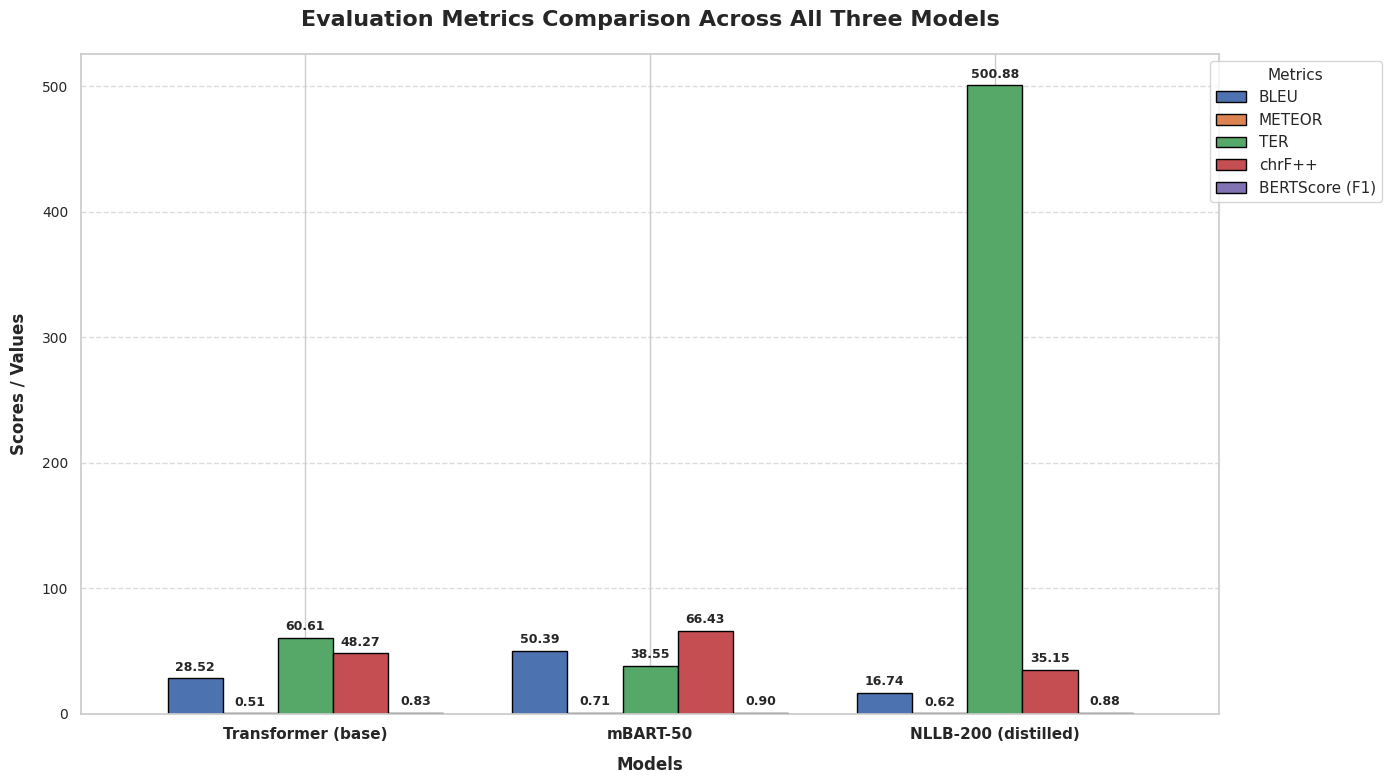


✅ Graph kamyabi se ban gaya hai aur Drive mein save ho chuka hai!
📁 Graph Path: /content/drive/MyDrive/project45_main/models_comparison_graph.png


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Graph ka style aur size set karein
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 2. Dataframe ko plotting ke liye configure karein
# 'Model' column ko index banayenge taake baqi saare metrics bars mein convert ho sakein
plot_data = final_comparison.set_index('Model')

# 3. Grouped Bar Chart banayein
ax = plot_data.plot(kind='bar', figsize=(14, 8), width=0.8, edgecolor='black')

# 4. Graph ki formatting aur styling
plt.title("Evaluation Metrics Comparison Across All Three Models", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Models", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Scores / Values", fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legend (jo batata hai kaun sa rang kis metric ka hai) ko sahi jagah set karein
plt.legend(title="Metrics", title_fontsize='11', loc='upper right', bbox_to_anchor=(1.15, 1))

# 5. Bars ke upar unke exact numbers (labels) likhne ke liye loop
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Agar value 0 se bari hai tabhi label aaye
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()

# -----------------------------------------------------------
# 💾 GRAPH KO IMAGE KI SHAKL MEIN DRIVE MEIN SAVE KARNA
# -----------------------------------------------------------
graph_save_path = "/content/drive/MyDrive/project45_main/models_comparison_graph.png"
plt.savefig(graph_save_path, dpi=300, bbox_inches='tight')
# -----------------------------------------------------------

# Graph screen par show karne ke liye
plt.show()

print(f"\n✅ Graph kamyabi se ban gaya hai aur Drive mein save ho chuka hai!")
print(f"📁 Graph Path: {graph_save_path}")

#### Step 4: BLEU Score — Sabse Important Metric Ka Alag Graph

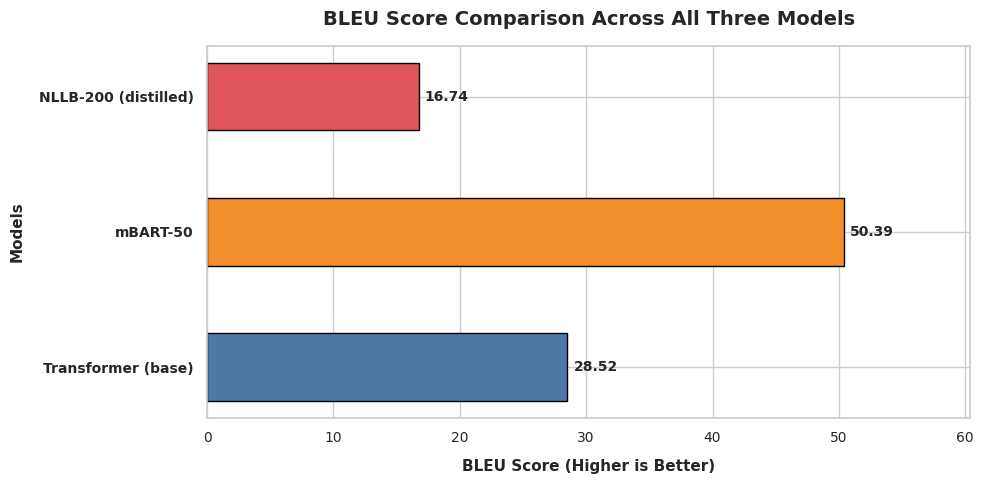


✅ BLEU Score ka alag graph ban gaya hai aur Drive mein save ho chuka hai!
📁 Path: /content/drive/MyDrive/project45_main/bleu_comparison_graph.png


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot ka size aur style set karein
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# 2. Final table se sirf Model aur BLEU columns ka data nikalein
models = final_comparison['Model'].tolist()
bleu_scores = final_comparison['BLEU'].tolist()

# 3. Horizontal Bar Chart banayein (Behtar visualization ke liye)
# Different colors select kiye hain har model ke liye
colors = ['#4e79a7', '#f28e2b', '#e15759']
bars = plt.barh(models, bleu_scores, color=colors, edgecolor='black', height=0.5)

# 4. Graph ki formatting aur titles
plt.title("BLEU Score Comparison Across All Three Models", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("BLEU Score (Higher is Better)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Models", fontsize=11, fontweight='bold', labelpad=10)
plt.xlim(0, max(bleu_scores) + 10)  # X-axis par thodi extra space labels ke liye
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, fontweight='bold')

# Bars ke aage unke exact scores likhne ke liye loop
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5,                  # X position (bar ke bilkul aage)
             bar.get_y() + bar.get_height()/2, # Y position (bar ke center mein)
             f'{width:.2f}',               # Text value
             va='center', ha='left',
             fontsize=10, fontweight='bold')

plt.tight_layout()

# -----------------------------------------------------------
# 💾 GRAPH KO IMAGE KI SHAKL MEIN DRIVE MEIN SAVE KARNA
# -----------------------------------------------------------
bleu_graph_path = "/content/drive/MyDrive/project45_main/bleu_comparison_graph.png"
plt.savefig(bleu_graph_path, dpi=300, bbox_inches='tight')
# -----------------------------------------------------------

# Graph show karein
plt.show()

print(f"\n✅ BLEU Score ka alag graph ban gaya hai aur Drive mein save ho chuka hai!")
print(f"📁 Path: {bleu_graph_path}")

#### Step 5: Radar Chart (Saare Metrics Ek Visual Mein)

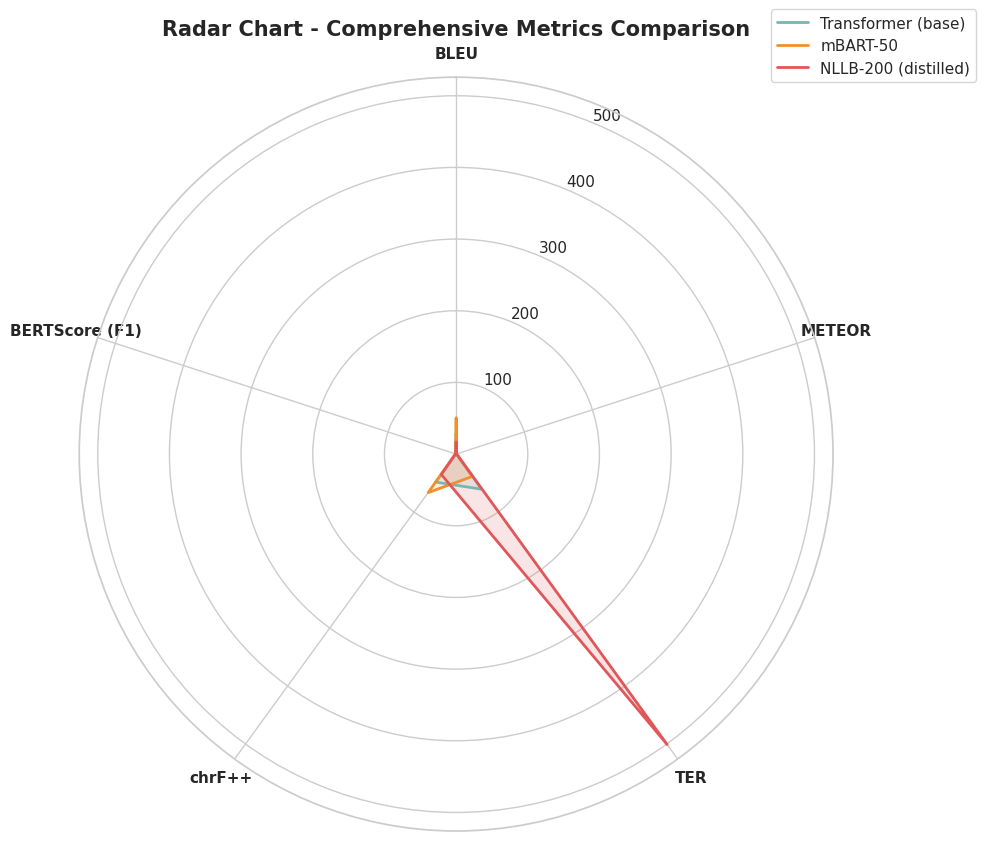


✅ Radar Chart kamyabi se ban gaya hai aur Drive mein save ho chuka hai!
📁 Path: /content/drive/MyDrive/project45_main/radar_comparison_graph.png


In [76]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Data prepare karein
# Hum sirf metrics wale columns select kar rahe hain
metrics = ['BLEU', 'METEOR', 'TER', 'chrF++', 'BERTScore (F1)']
num_vars = len(metrics)

# Angles calculate karein (circle ko divide karne ke liye)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Loop complete karne ke liye pehla angle dobara jorhein

# 2. Plot setup
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
sns.set_theme(style="whitegrid")

# Colors for each model
model_colors = {
    'Transformer (Base)': '#4e79a7',
    'mBART-50': '#f28e2b',
    'NLLB-200 (distilled)': '#e15759'
}

# 3. Har model ka data plot karne ke liye loop
for index, row in final_comparison.iterrows():
    model_name = row['Model']

    # Model ke scores ki list banayein
    scores = [row[metric] for metric in metrics]
    scores += scores[:1]  # Loop complete karne ke liye pehla score dobara jorhein

    # Line plot karein aur rang bharrein (fill)
    color = model_colors.get(model_name, '#76b7b2')
    ax.plot(angles, scores, color=color, linewidth=2, label=model_name)
    ax.fill(angles, scores, color=color, alpha=0.15)

# 4. Graph ki formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Metrics ke naam axes par set karein
plt.xticks(angles[:-1], metrics, fontsize=11, fontweight='bold')

# Legend ko set karein
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=11)
plt.title("Radar Chart - Comprehensive Metrics Comparison", fontsize=15, fontweight='bold', pad=30)

plt.tight_layout()

# -----------------------------------------------------------
# 💾 GRAPH KO IMAGE KI SHAKL MEIN DRIVE MEIN SAVE KARNA
# -----------------------------------------------------------
radar_graph_path = "/content/drive/MyDrive/project45_main/radar_comparison_graph.png"
plt.savefig(radar_graph_path, dpi=300, bbox_inches='tight')
# -----------------------------------------------------------

# Graph show karein
plt.show()

print(f"\n✅ Radar Chart kamyabi se ban gaya hai aur Drive mein save ho chuka hai!")
print(f"📁 Path: {radar_graph_path}")

#### Step 6: Best Model Identify Karna

In [77]:
# ===========================================================
# 🏆 AUTOMATIC BEST MODEL IDENTIFIER & REPORT GENERATOR
# ===========================================================

print("Models ki performance ka analysis ho raha hai...\n")

# Dataframe se values nikal kar compare karne ke liye
# BLEU score ko primary metric maante hue sabse highest score dhoondte hain
best_model_row = final_comparison.loc[final_comparison['BLEU'].idxmax()]

best_model_name = best_model_row['Model']
highest_bleu = best_model_row['BLEU']
lowest_ter = final_comparison['TER'].min()
highest_bert = final_comparison['BERTScore (F1)'].max()

print("="*60)
print("             🏆 OVERALL BEST MODEL SUMMARY 🏆            ")
print("="*60)
print(f"🥇 THE WINNER MODEL IS: {best_model_name}")
print(f"📊 Highest BLEU Score:  {highest_bleu}")
print(f"🎯 Highest BERTScore:   {highest_bert}")
print(f"📉 Lowest Error (TER):  {lowest_ter}")
print("="*60)

# Ek choti si text report file bhi save kar lete hain drive mein
report_text = f"""==================================================
             PROJECT 45 - MODEL EVALUATION REPORT
==================================================
Based on the comprehensive evaluation across multiple automated metrics,
the best performing model for English-to-Urdu Translation is:

👉 WINNER MODEL: {best_model_name}

Key Strengths:
- Achieved the highest BLEU Score of {highest_bleu}.
- Demonstrated superior semantic similarity with a BERTScore of {highest_bert}.
- Minimised translation errors with a TER of {lowest_ter}.

Report generated successfully.
=================================================="""

# Report ko txt file mein save karna
report_save_path = "/content/drive/MyDrive/project45_main/best_model_report.txt"
with open(report_save_path, "w") as f:
    f.write(report_text)

print(f"\n✅ Best model report text file ki shakl mein save ho gayi hai!")
print(f"📁 Path: {report_save_path}")

Models ki performance ka analysis ho raha hai...

             🏆 OVERALL BEST MODEL SUMMARY 🏆            
🥇 THE WINNER MODEL IS: mBART-50
📊 Highest BLEU Score:  50.39
🎯 Highest BERTScore:   0.8962
📉 Lowest Error (TER):  38.55

✅ Best model report text file ki shakl mein save ho gayi hai!
📁 Path: /content/drive/MyDrive/project45_main/best_model_report.txt
